## **Import Dataset**

In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Administrator\Downloads\archive (1)\PS_20174392719_1491204439457_log.csv")
df.shape

(6362620, 11)

In [2]:
df = df.drop_duplicates()

In [3]:
df.columns = df.columns.str.lower()

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameorig        object 
 4   oldbalanceorg   float64
 5   newbalanceorig  float64
 6   namedest        object 
 7   oldbalancedest  float64
 8   newbalancedest  float64
 9   isfraud         int64  
 10  isflaggedfraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
df.head()

,step,type,amount,nameorig,oldbalanceorg,newbalanceorig,namedest,oldbalancedest,newbalancedest,isfraud,isflaggedfraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
df.isnull().sum()

step              0
type              0
amount            0
nameorig          0
oldbalanceorg     0
newbalanceorig    0
namedest          0
oldbalancedest    0
newbalancedest    0
isfraud           0
isflaggedfraud    0
dtype: int64

## **EXPLORATORY DATA ANALYSIS**

In [7]:
df.head()

,step,type,amount,nameorig,oldbalanceorg,newbalanceorig,namedest,oldbalancedest,newbalancedest,isfraud,isflaggedfraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [8]:
df.value_counts('type')

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [9]:
df.head()

,step,type,amount,nameorig,oldbalanceorg,newbalanceorig,namedest,oldbalancedest,newbalancedest,isfraud,isflaggedfraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [10]:
df['isfraud'].value_counts()

isfraud
0    6354407
1       8213
Name: count, dtype: int64

In [11]:
df['isfraud'].mean()*100

np.float64(0.12908204481801522)

In [12]:
df['isflaggedfraud'].mean()*100

np.float64(0.000251468734577894)

In [13]:
df.groupby('type')['amount'].agg(['count', 'sum', 'mean'])

,count,sum,mean
type,,,
CASH_IN,1399284,2.363674e+11,168920.242004
CASH_OUT,2237500,3.944130e+11,176273.964346
DEBIT,41432,2.271992e+08,5483.665314
PAYMENT,2151495,2.809337e+10,13057.604660
TRANSFER,532909,4.852920e+11,910647.009645


In [14]:
df.groupby('type')['isfraud'].sum()

type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isfraud, dtype: int64

In [15]:
df.head()

,step,type,amount,nameorig,oldbalanceorg,newbalanceorig,namedest,oldbalancedest,newbalancedest,isfraud,isflaggedfraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [16]:
df.groupby('type')['isflaggedfraud'].sum()

type
CASH_IN      0
CASH_OUT     0
DEBIT        0
PAYMENT      0
TRANSFER    16
Name: isflaggedfraud, dtype: int64

## **FEATURE ENGINEERING**

In [17]:
df.value_counts('step')

step
19     51352
18     49579
187    49083
235    47491
307    46968
       ...  
432        4
706        4
693        4
112        2
662        2
Name: count, Length: 743, dtype: int64

In [18]:
df['hour'] = df['step'] % 24

In [19]:
df.value_counts('hour')

hour
19    647814
18    580509
20    553728
12    483418
13    468474
11    445992
16    441612
17    439941
14    439653
10    425729
15    416686
9     283518
21    247806
22    194555
23    141257
0      71587
1      27111
8      26915
2       9018
7       8988
6       3420
3       2007
5       1641
4       1241
Name: count, dtype: int64

In [20]:
df.groupby('hour')['isfraud'].count().sort_values(ascending=False).head(10)

hour
19    647814
18    580509
20    553728
12    483418
13    468474
11    445992
16    441612
17    439941
14    439653
10    425729
Name: isfraud, dtype: int64

In [21]:
from numpy import astype
df['high_value_tx'] = (df['amount'] > 200000).astype(int)

In [22]:
df.groupby('type')['isfraud'].sum()

type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isfraud, dtype: int64

In [23]:
df['high_risk_type'] = df['type'].isin(['CASH_OUT', 'TRANSFER']).astype(int)

In [24]:
df['emptied_account'] = ((df['oldbalanceorg'] > 0) & (df['newbalanceorig'] == 0) & (df['amount'] >= df['oldbalanceorg'])).astype(int)

In [25]:
df.head()

,step,type,amount,nameorig,oldbalanceorg,newbalanceorig,namedest,oldbalancedest,newbalancedest,isfraud,isflaggedfraud,hour,high_value_tx,high_risk_type,emptied_account
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,1,0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1,0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,1,0,1,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,1,0,1,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,1,0,0,0


In [26]:
df['risk_score'] = df['high_value_tx'] * 1 + df['high_risk_type'] * 2 + df['emptied_account'] * 3

## **Visual (EDA)**

### **Transaction Types Distribution**

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

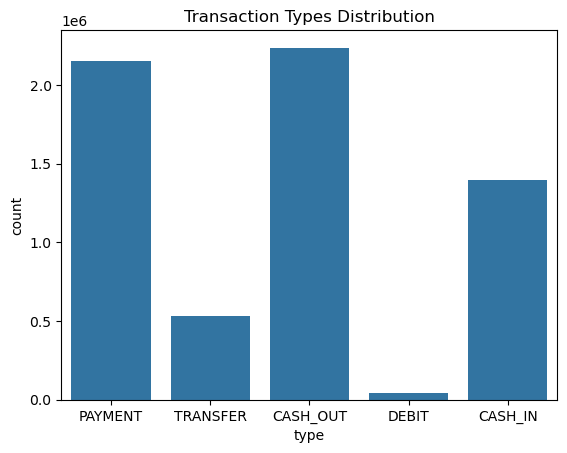

In [28]:
sns.countplot(x='type', data=df)
plt.title('Transaction Types Distribution')
plt.show()

### **Fraud Rate By Type**

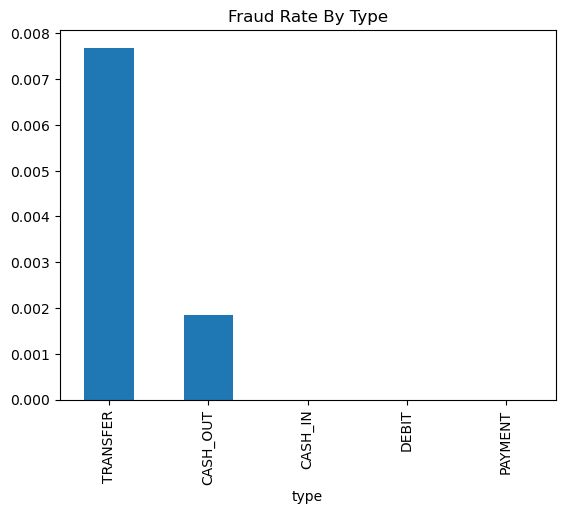

In [29]:
fraud_by_type = df.groupby('type')['isfraud'].mean().sort_values(ascending=False)

fraud_by_type.plot(kind='bar')
plt.title('Fraud Rate By Type')
plt.show()

### **Fraud VS Amount**

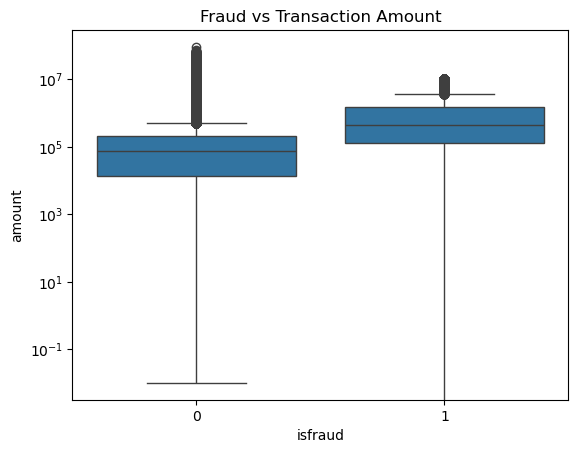

In [30]:
sns.boxplot(x='isfraud', y='amount', data=df)

plt.yscale('log')
plt.title("Fraud vs Transaction Amount")
plt.show()

### **Fraud By Hour**

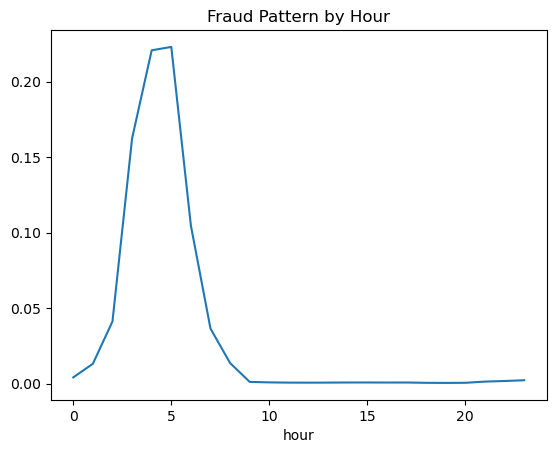

In [36]:
hourly_fraud = df.groupby('hour')['isfraud'].mean()

hourly_fraud.plot()
plt.title('Fraud Pattern by Hour')
plt.show()

## **Suspicious Accounts Detection**

### **Top Fraud Senders**

In [37]:
top_senders = df[df['isfraud'] == 1]['nameorig'].value_counts().head(10)
print(top_senders)

nameorig
C1305486145    1
C755286039     1
C973279667     1
C258213312     1
C1640703547    1
C1127265876    1
C317779855     1
C1064034527    1
C1141104763    1
C1966863341    1
Name: count, dtype: int64


### **Top Fraud Receivers**

In [39]:
top_receivers = df[df['isfraud'] == 1]['namedest'].value_counts().head(10)
print(top_receivers)

namedest
C1193568854    2
C104038589     2
C200064275     2
C1497532505    2
C1601170327    2
C1655359478    2
C2020337583    2
C1653587362    2
C1013511446    2
C2129197098    2
Name: count, dtype: int64


## **Bussiness KPI's IMP**

In [43]:
total_txn = len(df)
total_txn_amount = df['amount'].sum()
fraud_txn = df['isfraud'].sum()
fraud_rate = fraud_txn / total_txn * 100

print("Total Transactions:", total_txn)
print("Total Transaction Amount:", total_txn_amount)
print("Fraud Transactions:", fraud_txn)
print("Fraud Rate:", fraud_rate)

Total Transactions: 6362620
Total Transaction Amount: 1144392944759.77
Fraud Transactions: 8213
Fraud Rate: 0.12908204481801522


## **Risk Segmentation**

In [44]:
df['risk_level'] = pd.cut(df['risk_score'], bins=[-1, 1, 3, 6], labels=['Low', 'Medium', 'High'])

df['risk_level'].value_counts()

risk_level
Low       3259704
Medium    1914824
High      1188092
Name: count, dtype: int64

In [33]:
df.columns

Index(['step', 'type', 'amount', 'nameorig', 'oldbalanceorg', 'newbalanceorig',
       'namedest', 'oldbalancedest', 'newbalancedest', 'isfraud',
       'isflaggedfraud', 'hour', 'high_value_tx', 'high_risk_type',
       'emptied_account', 'risk_score'],
      dtype='object')